In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/monthly_sales.csv")
df["date"] = pd.to_datetime(df["date"])
ts = df.set_index("date")["sales"]

train_size = int(len(ts) * 0.8)
train = ts[:train_size]
test = ts[train_size:]

In [2]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.67340891732597
p-value: 0.44486243662973274


In [3]:
train_diff = train.diff().dropna()

In [4]:
result = adfuller(train_diff)
print("p-value after differencing:", result[1])

p-value after differencing: 0.0051060285974883724


In [6]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                   23
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -303.673
Date:                Fri, 01 May 2026   AIC                            613.345
Time:                        07:22:14   BIC                            616.618
Sample:                    01-31-2003   HQIC                           614.116
                         - 11-30-2004                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4897      2.677      0.183      0.855      -4.757       5.736
ma.L1         -0.7789      2.256     -0.345      0.730      -5.200       3.642
sigma2      7.045e+10   2.39e-10   2.95e+20      0.0

C:\Users\SRIDHAR\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\SRIDHAR\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\SRIDHAR\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [7]:
pred_arima = model_fit.forecast(steps=len(test))

In [12]:
print(pred_arima)

2004-12-31    884539.434995
2005-01-31    784400.880663
2005-02-28    735367.581872
2005-03-31    711358.204001
2005-04-30    699601.902876
2005-05-31    693845.376535
Freq: ME, Name: predicted_mean, dtype: float64


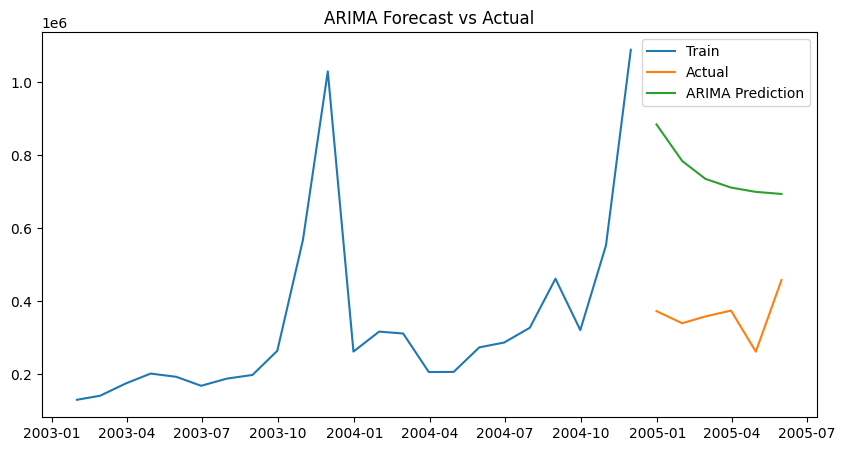

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(test.index, pred_arima, label="ARIMA Prediction")

plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, pred_arima)
rmse = np.sqrt(mean_squared_error(test, pred_arima))
mape = np.mean(np.abs((test - pred_arima) / test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 390804.00182346697
RMSE: 400661.31561633723
MAPE: 113.76578127123918


In [10]:
pred_df = pd.DataFrame({
    "date": test.index,
    "actual": test.values,
    "arima_pred": pred_arima.values
})

pred_df.to_csv("../outputs/metrics/arima_predictions.csv", index=False)

In [11]:
import joblib

joblib.dump(model_fit, "../models/arima.pkl")

['../models/arima.pkl']